# 詳細解析スクリプト

Log:

 - "パラメタ分布調査・異常時再フィット付き" fb70d8fbeb53a2451e1d8a4b631d36e12fa95af8
    - fit結果chi2>4.0なら初期値変えて再フィット
    - fit異常報告削除
 - "関数フィット妥当性調査、更新前整形 "6c042e64baceda6d20e5ab91fc63d0904ce7e3c9
 - "関数フィット妥当性調査" a6b852e6fb0947ba37100297674a4a7cfa18cbed
    - パラメタ beta の分布を調査、betaは(-0.5 - 0.5)に分布してる(負を含む)
    - 異常値発見(1サンプル＠PKS2155-304), fitがうまくいってなかった


## 関数フィットの妥当性調査
全てのフィット結果を保存し、全体とピーク検出のものそれぞれについて（全体はさらに全天体と各天体、1dと14dと両方、について）、
以下を作成：
 - パラメタ分布hist
 - パラメタvs不定性散布図
 
## 主要部分

In [95]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack
from astropy.modeling.powerlaws import LogParabola1D
from astropy.modeling import models, fitting
from astropy import units as u
from scipy.optimize import curve_fit
from scipy.stats import chi2, norm


### ピーク検出・有意度計算

In [96]:
################################################
### # Peak significance calculation - not used
### This must be used with the listing of all the data points
### of consecutive positive deviations, 
### which can be more than three
################################################
def calc_peak_significance(ri):
#     '''
#     fit (array) values for the fit
#     x,y,yerr (arrays) data
#     N total number of points
#     n_free number of parameters we are fitting
#     '''
#     return 1.0/(N-n_free)*sum(((fit - y)/yerr)**2)
# import numpy as np
# from scipy.stats import chi2, norm
# # only those residuals that form the (at least) 3 consecutive positive deviations
# ri = np.array([1, 2, 3.])

# # Chi-square of those residuals
  chi2_value = np.sum(ri**2)

# # p-value for chi-square with m degrees of freedom - m = len(ri) - this is the probability of obtaining a test statistic at least as high as chi2_value
  p_val = 1 - chi2.cdf(chi2_value, df=len(ri))

# # p-value to Gaussian-equivalent one-sided significance
  sigma_equiv = norm.ppf(1 - p_val)

  return p_val, sigma_equiv


###################
# Peak detection
###################
def get_consecutive_bins_for_multi_peaks(s,nconsecutive = 3 ):
  # from s, find all the sets of consecutive bins that have values > 1.0 for at least nconsecutive bins
  # return the list of (peakinitbin, peaklength, significance)s
  peakinitbins=[]
  peaklengths=[]
  significances=[]
  peakinitbin = -1
  for i in range(0,len(s)-nconsecutive+1):  
    if np.all(s[i:i+nconsecutive] > 1.0):
      if peakinitbin < 0:
        peakinitbin = i
      if i + nconsecutive == len(s):
        peakinitbins.append(peakinitbin)
        peaklengths.append(i + nconsecutive - peakinitbin)
        significances.append(calc_peak_significance(s[peakinitbin:i+nconsecutive]))
        return   peakinitbins,peaklengths,significances
    else:
      if peakinitbin >= 0:
        peakinitbins.append(peakinitbin)
        peaklengths.append(i + nconsecutive -1 - peakinitbin)
        significances.append(calc_peak_significance(s[peakinitbin:i+nconsecutive-1]))
        peakinitbin = -1
  return   peakinitbins,peaklengths,significances

def get_consecutive_bins(s,nconsecutive = 3 ):
  peakinitbin = -1
  for i in range(0,len(s)-nconsecutive+1):
    # print(i)
    if np.all(s[i:i+nconsecutive] > 1.0):
      #   print(i)
      #   print(s[i:i+nconsecutive])
      #   print('---')
      if peakinitbin < 0:
        peakinitbin = i
        # print('Found peak at bin#:',peakinitbin)
        # print(s[peakinitbin:i+nconsecutive])
      if i + nconsecutive == len(s):
        # print('Last bin reached', i, 'for the length ',len(s))
        # print('End of peak at bin #:',i + nconsecutive -1, 'length ', i + nconsecutive - peakinitbin)
        # print(s[peakinitbin:i+nconsecutive])
        # print(peakinitbin, i+ nconsecutive - peakinitbin)
        return peakinitbin, i+ nconsecutive - peakinitbin, calc_peak_significance(s[peakinitbin:i+nconsecutive])
    else:
      if peakinitbin >= 0:
        # print('End of peak at bin#:',i + nconsecutive -2, 'length ', i -1 + nconsecutive - peakinitbin)
        # print(s[peakinitbin:i+nconsecutive ])
        # print(peakinitbin, i+ nconsecutive -1 - peakinitbin)
        return peakinitbin, i+ nconsecutive -1 - peakinitbin, calc_peak_significance(s[peakinitbin:i+nconsecutive-1])
        # if peakbininit[0] > 0:
        #   print('Found longer peak at bin:',peakbininit[0] , 'in total length of ', len(s))
        # else :
        #   print('Longest peak at bin:',i ,'length ', nconsecutive, 'in total length of ', len(s))
  return -1, 0


### 主体関数

In [97]:

nbinsmin=9

###################
# Utility functions
###################
def gaussian(x, amplitude, mu, sigma):
    # return (1.0 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2) : Normal distribution
    return amplitude * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def calc_reduced_chi_square(fit, x, y, yerr, N, n_free):
    '''
    fit (array) values for the fit
    x,y,yerr (arrays) data
    N total number of points
    n_free number of parameters we are fitting
    '''
    return 1.0/(N-n_free)*sum(((fit - y)/yerr)**2)

###################
# Main function
###################
def eval_spectra(filepath,suffix='',sourcename=''): #'data/3C454.3_allsed_14d_min11.ecsv'
  nconsecutive = 3
  sourcenameheader = ''
  if suffix != '':
    sourcenameheader = suffix + '_'

  if sourcename == '':
    sourcename = filepath.split('_')[0]
    sourcename = sourcename.replace('data/', '')
  # logpar_init = LogParabola1D(amplitude=1,x_0=10,alpha=1,beta=1)
  logpar_init = LogParabola1D(
    amplitude = 0.000016494113774149846,
    x_0 = 9.482855296727278,
    alpha = -0.5677548858840729,
    beta=0)
    # beta = 0.1071613245072173)

  ### initialize a linear fitter ###
  # fit = fitting.TRFLSQFitter()
  fit = fitting.DogBoxLSQFitter()

  ### Read the data ###
  t0 = Table.read(filepath)
  nonzero_mask = (t0['e2dnde'] > t0['e2dnde_err'])
  t = t0[nonzero_mask]

  ### MJDごとに処理 ###
  obsdates=np.unique(t['tstart'].data).tolist()
  n_detected_peaks = 0
  array_nbins = []
  array_chisq = []
  # t_peakstat = Table(names = ['peak length','SED length','p-value','sigma'], dtype = ['i2','i2','f4' ,'f4'])
  t_fitstat =  Table(names = ['fit chisq','alpha','beta','amplitude','x_0',
                              'alpha_err','beta_err','amplitude_err','x_0_err',
                              'is_peak','nbins','obsdate' ], dtype = ['f4','f4','f4' ,'f4','f4','f4','f4' ,'f4','f4','i2','i2','f4' ])
  for idx, obsdate in enumerate(obsdates):
    # print(idx, ': obsdate',obsdate)
    mask = (t['tstart']==obsdate)
    x = t[mask]['e_ref']
    y = t[mask]['e2dnde']
    yerr = t[mask]['e2dnde_err']
    nbins = len(x)
    if nbins < nbinsmin:
        print('nbins < nbinsmin:',nbins)
        continue
    array_nbins.append(nbins)
    
    ### fit the data with the fitter ###
    # logpar_init.amplitude.value=x[1]*1.0e-8
    fitted_line = fit(logpar_init, x,y,weights=1.0/yerr, maxiter=200)
    residuals = (y-fitted_line(x))/yerr
    # print(fit.fit_info)
    # residuals = (fitted_line(x)-y)/yerr # negative:dip finding
    reduced_chi_squared = calc_reduced_chi_square(fitted_line(x), x, y, yerr, len(x), 4)
    array_chisq.append(reduced_chi_squared)
    if reduced_chi_squared > 4.0:
      # refit with another beta 
      logpar_init.beta.value = 0.1
      fitted_line = fit(logpar_init, x,y,weights=1.0/yerr, maxiter=200)
      residuals = (y-fitted_line(x))/yerr
      reduced_chi_squared = calc_reduced_chi_square(fitted_line(x), x, y, yerr, len(x), 4)  
    
    peakinitbins,peaklengths,significances = get_consecutive_bins_for_multi_peaks(residuals,nconsecutive)
    # peakbininit = get_consecutive_bins(residuals,nconsecutive)
    # fill the table with the fit results
    is_peak = 0 # not a peak  
    # if peakbininit[0] > 0:
    if len(peakinitbins) > 0:
      is_peak = 1 # is a peak
      n_detected_peaks += 1
    t_fitstat.add_row([reduced_chi_squared,
                      fitted_line.alpha.value,
                      fitted_line.beta.value,
                      fitted_line.amplitude.value,  
                      fitted_line.x_0.value,
                      np.sqrt(fit.fit_info['param_cov'][fitted_line.param_names.index('alpha'), fitted_line.param_names.index('alpha')]),
                      np.sqrt(fit.fit_info['param_cov'][fitted_line.param_names.index('beta'), fitted_line.param_names.index('beta')]),
                      np.sqrt(fit.fit_info['param_cov'][fitted_line.param_names.index('amplitude'), fitted_line.param_names.index('amplitude')]),
                      np.sqrt(fit.fit_info['param_cov'][fitted_line.param_names.index('x_0'), fitted_line.param_names.index('x_0')]),
                      is_peak,
                      nbins,obsdate
                     ])
      # print('Found peak at bin:',peakbininit[0], 'length ', peakbininit[1], 'in total length of ', len(residuals), 'p-value, sigma:', peakbininit[2])
      # t_peakstat.add_row([peakbininit[1], len(residuals), peakbininit[2][0], peakbininit[2][1]])
  # print(t_peakstat)
  return t_fitstat

In [114]:
# import numpy as np
# import matplotlib.pyplot as plt
# from astropy.table import Table, vstack
# from astropy.modeling.powerlaws import LogParabola1D
# from astropy.modeling import models, fitting
# from astropy import units as u
# from scipy.optimize import curve_fit

nconsecutive = 3

def plotSED_erg_GeV(x, y, yerr, fitted_line, peakbininit, nconsecutive, residuals,reduced_chi_squared, obsdate, idx, sourcename=""):
  
  y_scalefactor= (y.to(u.Unit("erg cm-2 s-1")).value/y.value)[0]
  model_y = fitted_line(x) * y_scalefactor
  
  x = x.to(u.GeV).value  
  y = y.to(u.Unit("erg cm-2 s-1")).value
  yerr = yerr.to(u.Unit("erg cm-2 s-1")).value
  
   # Plot the SED with the fitted line, with the residual plot at the bottom
  fig = plt.figure(figsize=(10, 6))
  frame1=fig.add_axes((.1,.3,.8,.6))
  plt.errorbar(x, y, yerr=yerr, marker='o', linestyle='', label='Data')
  plt.plot(x, model_y, '-', label='Fitted Line')
  # plt.plot(x[peakbininit:peakbininit+nconsecutive],
  #          y[peakbininit:peakbininit+nconsecutive], label='Peak Region', marker='x', linestyle='-')
  # plt.title(f"Observation {idx}: MJD {int(obsdate)} "+ r"$\chi^2$/ndf=" +f" {reduced_chi_squared:.2f}")
  # plt.title(f"GB6J1040+0617 : MJD {int(obsdate)} "+ r"$\chi^2$/ndf=" +f" {reduced_chi_squared:.2f}")
  plt.title(f"{sourcename} : MJD {round(obsdate,3)} "+ r"$\chi^2$/ndf=" +f" {reduced_chi_squared:.2f}")
  plt.xlabel('Energy [GeV]')
  plt.ylabel(r"E$^2d\phi/d$E [erg/cm$^{-2}$ s$^{-1}$]")
  plt.xscale('log')
  plt.yscale('log')
  # plt.xlim(100, 3e3)
  # plt.ylim(1e-2, 2) # for GB6J1040+0617
  # plt.ylim(1e-4, 2e-3)

  plt.legend()

  frame2=fig.add_axes((.1,.1,.8,.2))  
  plt.plot(x, residuals, '.', label='Residuals')
  plt.axhline(0, color='red', linestyle='--', label='Zero Line')
  plt.xlabel('Energy [GeV]')
  plt.ylabel('Residuals')
  plt.xscale('log')
  plt.legend()
  plt.tight_layout()

  # plt.xlim(100, 3e3)
  plt.show()


def show_SED(filepath,target_MJD, range_days): #'data/3C454.3_allsed_14d_min11.ecsv'
  sourcename = filepath.split('_')[0]
  sourcename = sourcename.replace('data/', '')
  # logpar_init = LogParabola1D(amplitude=1,x_0=10,alpha=1,beta=1)
  logpar_init = LogParabola1D(
    amplitude = 0.000016494113774149846,
    x_0 = 9.482855296727278,
    alpha = -0.5677548858840729,
    beta=0)
    # beta = 0.1071613245072173)

  ### initialize a linear fitter ###
  # fit = fitting.TRFLSQFitter()
  fit = fitting.DogBoxLSQFitter()
  
  ### Read the data ###
  t0 = Table.read(filepath)
  nonzero_mask = (t0['e2dnde'] > t0['e2dnde_err'])
  t = t0[nonzero_mask]

  ### MJDごとに処理 ###
  obsdates=np.unique(t['tstart'].data).tolist()

  for obsdate in obsdates:
    if obsdate < target_MJD - range_days or obsdate > target_MJD + range_days:
      continue
    # print(idx, ': obsdate',obsdate)
    mask = (t['tstart']==obsdate)
    x = t[mask]['e_ref']
    y = t[mask]['e2dnde']
    yerr = t[mask]['e2dnde_err']
    fitted_line = fit(logpar_init, x,y,weights=1.0/yerr, maxiter=200)
    reduced_chi_squared = calc_reduced_chi_square(fitted_line(x), x, y, yerr, len(x), 4)
    if reduced_chi_squared > 4.0:
      # refit with another beta 
      logpar_init.beta.value = 0.1
      fitted_line = fit(logpar_init, x,y,weights=1.0/yerr, maxiter=200)
      reduced_chi_squared = calc_reduced_chi_square(fitted_line(x), x, y, yerr, len(x), 4)  
    residuals = (y-fitted_line(x))/yerr    
    peakbininit = get_consecutive_bins(residuals,nconsecutive)
    plotSED_erg_GeV(x, y , yerr, fitted_line, peakbininit, nconsecutive, residuals, reduced_chi_squared, obsdate, 0,sourcename)
    print(fitted_line)

### 実行テスト

In [99]:
# eval_spectra('data/3C454.3_allsed_14d_min11.ecsv')  # 2pos, 0neg/264
# eval_spectra('data/3C454.3_allsed_1d_min11.ecsv')  # 8pos
# eval_spectra('data/BLLac_allsed_14d_min11.ecsv')
# eval_spectra('data/BLLac_allsed_1d_min11.ecsv') 
# eval_spectra('data/3C279_allsed_14d_min11.ecsv') 
# eval_spectra('data/3C279_allsed_1d_min11.ecsv') 
# eval_spectra('data/CTA102_allsed_14d_min11.ecsv') 
t_fitstat = eval_spectra('data/CTA102_allsed_1d_min11.ecsv')

print(t_fitstat)

nbins < nbinsmin: 8
nbins < nbinsmin: 7
nbins < nbinsmin: 7
nbins < nbinsmin: 8
nbins < nbinsmin: 8
nbins < nbinsmin: 8
fit chisq     alpha          beta       amplitude    ... is_peak nbins obsdate
---------- ------------ ------------- -------------- ... ------- ----- -------
 0.6268421   -1.3288404    0.19520476   2.967318e-05 ...       0    10 55719.7
 1.2141738   0.17356396 -0.0018859803  0.00036738123 ...       0    12 55721.7
0.45347327  0.093398154   0.013294225  0.00043782833 ...       0    13 56182.7
0.73268455 -0.093381524   0.009867276  0.00011900239 ...       0    11 56187.7
 1.1085442  -0.66823304   0.071186714   7.660314e-05 ...       0    14 56188.7
0.35205165   0.21322608  -0.029456332  0.00027031396 ...       0    12 56189.7
 1.1839178  -0.58162016   0.044264186   8.129375e-05 ...       0    15 56191.7
  1.563007  -0.24460796   0.009220716   0.0002858553 ...       0    18 56192.7
 1.1908358  0.121130414  -0.016366225   0.0007036139 ...       0    15 56193.7
 2.1298325 

## 全データ解析
### 天体名対応辞書作成
### - 辞書定義(4FGLカタログ準拠)

In [101]:
from astropy.io import fits
import numpy as np

def get_dict_sourcenames():
  num_sources = 2300
  hdu=fits.open('/Users/kazuma/Workspace/Torun/Fermi/catalog/gll_psc_v35.fit')
  significances = hdu[1].data['Signif_Avg']
  sources = hdu[1].data['Source_Name']
  sources1 = hdu[1].data['ASSOC1']
  sources2 = hdu[1].data['ASSOC2']
  sources_cls=hdu[1].data['CLASS1']
  #Convert source classes to normal array without empty spaces
  source_classes = np.array([entry.strip() for entry in hdu[1].data['CLASS1']])
  #Filter by source class:
  source_classes_selected = np.array(["bll","fsrq","BLL","FSRQ"],dtype='<U5') #see table 5 in https://arxiv.org/pdf/2201.11184
  element_map = np.isin(source_classes, source_classes_selected)
  significances_blazars= significances[element_map]
  sources_blazars = sources[element_map]
  sources_blazars1 = sources1[element_map]
  sources_blazars2 = sources2[element_map]
  sources_blazars_cls = source_classes[element_map]
  #Get index of 20 brightes sources:
  idx = (-significances_blazars).argsort()[:num_sources]
  indices = np.arange(1,num_sources+1)
  # print(f"Number of sources: {len(sources_blazars[idx])}")
  # print(f"Indices of the sources: {indices}")
  #Get the same of the 20 most significant blazars:
  # print(sources_blazars[idx])
  from astropy.table import Table
  # t = Table([sources_blazars[idx],
  #   sources_blazars1[idx],
  #   sources_blazars_cls[idx],
  #   ],names=['4FGL name','assoc name','CLASS','index'])
  

  # sources_blazars_converted  = sources_blazars.strip().replace(' ','_').lower()
  sources_blazars_converted  = sources_blazars.strip().replace('4FGL ','').lower()
  sources_blazars1_converted = sources_blazars1.strip().replace(' ','_').lower()
  sources_blazars_selected_cls = sources_blazars_cls[idx]
  # print(sources_blazars_selected_cls)
  # print(sources_blazars_cls[idx])
  # The elements of sources_blazars_selected_cls are mixture of upper/lower cases. 
  # We unify them to upper case here.
  sources_blazars_selected_cls_converted = np.array([entry.upper() for entry in sources_blazars_selected_cls])
  # print(sources_blazars_selected_cls_converted)  

#   dict_sourcenames = dict(zip(sources_blazars_converted[idx],sources_blazars1_converted[idx]))

  ref_tab_obj = Table([sources_blazars_converted[idx],
  sources_blazars1_converted[idx],
  sources_blazars_selected_cls_converted, #sources_blazars_cls[idx], 
  indices],
  names=['4FGL name','assoc name','CLASS','index'])
# ref_tab_obj[ref_tab_obj['4FGL name'] == '4fgl_j0112.1+2245']
  return ref_tab_obj


### - 辞書生成

In [102]:
dict_sourcename = get_dict_sourcenames()
dict_sourcename[0:2]

4FGL name,assoc name,CLASS,index
str13,str28,str4,int64
j2253.9+1609,3c_454.3,FSRQ,1
j1104.4+3812,mkn_421,BLL,2


### - 天体名書き換え

In [103]:
dict_sourcename[0]['assoc name']  = '3C454.3' 
dict_sourcename[1]['assoc name']  = 'Mrk421' 
dict_sourcename[2]['assoc name']  = 'BLLac' 
dict_sourcename[3]['assoc name']  = 'CTA102' 
dict_sourcename[4]['assoc name']  = '3C279'
dict_sourcename[5]['assoc name']  = 'S50716+71' 
dict_sourcename[6]['assoc name']  = 'PKS1424-41' 
dict_sourcename[7]['assoc name']  = 'PKS0426-380'
dict_sourcename[8]['assoc name']  = 'PKS0537-441'
dict_sourcename[9]['assoc name']  = 'PKS2155-304'
dict_sourcename[10]['assoc name'] = 'PKS0454-234'
dict_sourcename[11]['assoc name'] = 'PKS1510-089'
dict_sourcename[12]['assoc name'] = 'PKS1502+106'
dict_sourcename[13]['assoc name'] = 'TON599'
dict_sourcename[14]['assoc name'] = 'PKS0346-27'
dict_sourcename[15]['assoc name'] = '4c+01.02'
dict_sourcename[16]['assoc name'] = '4c+55.17'
dict_sourcename[17]['assoc name'] = '4c+21.35'
dict_sourcename[18]['assoc name'] = 'PKS1830-211'
dict_sourcename[19]['assoc name'] = 'PKS0208-512'
dict_sourcename[0:15]

4FGL name,assoc name,CLASS,index
str13,str28,str4,int64
j2253.9+1609,3C454.3,FSRQ,1
j1104.4+3812,Mrk421,BLL,2
j2202.7+4216,BLLac,BLL,3
j2232.6+1143,CTA102,FSRQ,4
j1256.1-0547,3C279,FSRQ,5
j0721.9+7120,S50716+71,BLL,6
j1427.9-4206,PKS1424-41,FSRQ,7
j0428.6-3756,PKS0426-380,BLL,8
j0538.8-4405,PKS0537-441,BLL,9


## 実行

### 全20天体のテーブルを作成

In [104]:
n_brightest_sources = 20

table_14d = Table()
for sourceinfo in dict_sourcename[0:n_brightest_sources]:
  print(sourceinfo['assoc name'])
  filepath = 'data/' + sourceinfo['assoc name'].replace('_','').lower() + '_allsed_14d_min11.ecsv'
  t = eval_spectra(filepath)
  if len(t) == 0:
    continue
  t.add_column(np.ones(len(t))*14, name='Days scale')
  t.add_column(np.ones(len(t))*sourceinfo['index'], name='Index')
  t.add_column(np.array([sourceinfo['assoc name']]*len(t)), name='Source Name')
  t.add_column(np.array([sourceinfo['4FGL name']]*len(t)), name='4FGL Name')
  table_14d = vstack([table_14d, t])

print(table_14d)

3C454.3
Mrk421
nbins < nbinsmin: 6
nbins < nbinsmin: 8
nbins < nbinsmin: 8
nbins < nbinsmin: 7
nbins < nbinsmin: 8
BLLac
CTA102
3C279
nbins < nbinsmin: 8
S50716+71
nbins < nbinsmin: 8
PKS1424-41
PKS0426-380
nbins < nbinsmin: 7
nbins < nbinsmin: 8
nbins < nbinsmin: 8
nbins < nbinsmin: 8
PKS0537-441
PKS2155-304
nbins < nbinsmin: 6


    The maximum number of function evaluations is exceeded. [astropy.modeling.fitting]


nbins < nbinsmin: 8
nbins < nbinsmin: 7
nbins < nbinsmin: 8
nbins < nbinsmin: 8
nbins < nbinsmin: 8
nbins < nbinsmin: 8
nbins < nbinsmin: 8
nbins < nbinsmin: 8
nbins < nbinsmin: 6
nbins < nbinsmin: 8
nbins < nbinsmin: 8
nbins < nbinsmin: 7
nbins < nbinsmin: 8
PKS0454-234
nbins < nbinsmin: 8
nbins < nbinsmin: 8
PKS1510-089
PKS1502+106
TON599
PKS0346-27
4c+01.02
nbins < nbinsmin: 8
4c+55.17
nbins < nbinsmin: 8
nbins < nbinsmin: 7
nbins < nbinsmin: 8
nbins < nbinsmin: 8
nbins < nbinsmin: 8
nbins < nbinsmin: 8
nbins < nbinsmin: 7
4c+21.35
nbins < nbinsmin: 8
PKS1830-211
PKS0208-512
fit chisq     alpha        beta     ... Index Source Name  4FGL Name  
---------- ----------- ------------ ... ----- ----------- ------------
   1.60775  -0.7177362   0.12422504 ...   1.0     3C454.3 j2253.9+1609
 1.1422557   -0.302482   0.07985071 ...   1.0     3C454.3 j2253.9+1609
 0.6731053 -0.21605223   0.06918016 ...   1.0     3C454.3 j2253.9+1609
 0.7491521  -0.2671864  0.076810054 ...   1.0     3C454.3 j2

In [105]:
n_brightest_sources = 20

import os.path
table_1d = Table()
for sourceinfo in dict_sourcename[0:n_brightest_sources]:
  print(sourceinfo['assoc name'])
  filepath = 'data/' + sourceinfo['assoc name'].replace('_','').lower() + '_allsed_1d_min11.ecsv'
  if os.path.isfile(filepath) :
    t = eval_spectra(filepath)
    if len(t) == 0:
      continue
    t.add_column(np.ones(len(t))*1, name='Days scale')
    t.add_column(np.ones(len(t))*sourceinfo['index'], name='Index')
    t.add_column(np.array([sourceinfo['assoc name']]*len(t)), name='Source Name')
    t.add_column(np.array([sourceinfo['4FGL name']]*len(t)), name='4FGL Name')
    table_1d = vstack([table_1d, t])
  else:
    print('File not found:', filepath)
print(table_1d)


3C454.3
nbins < nbinsmin: 8
nbins < nbinsmin: 8
nbins < nbinsmin: 7
nbins < nbinsmin: 8
nbins < nbinsmin: 8
nbins < nbinsmin: 8
nbins < nbinsmin: 7
Mrk421
File not found: data/mrk421_allsed_1d_min11.ecsv
BLLac
nbins < nbinsmin: 8
nbins < nbinsmin: 8
nbins < nbinsmin: 8
nbins < nbinsmin: 8
nbins < nbinsmin: 8
nbins < nbinsmin: 8
nbins < nbinsmin: 6
CTA102
nbins < nbinsmin: 8
nbins < nbinsmin: 7
nbins < nbinsmin: 7
nbins < nbinsmin: 8
nbins < nbinsmin: 8
nbins < nbinsmin: 8
3C279
nbins < nbinsmin: 8
nbins < nbinsmin: 8
nbins < nbinsmin: 8
S50716+71
File not found: data/s50716+71_allsed_1d_min11.ecsv
PKS1424-41
nbins < nbinsmin: 8
nbins < nbinsmin: 8
nbins < nbinsmin: 8
nbins < nbinsmin: 7
nbins < nbinsmin: 8
nbins < nbinsmin: 8
nbins < nbinsmin: 8
nbins < nbinsmin: 8
nbins < nbinsmin: 8
nbins < nbinsmin: 7
nbins < nbinsmin: 8
nbins < nbinsmin: 8
nbins < nbinsmin: 6
nbins < nbinsmin: 8
nbins < nbinsmin: 8
PKS0426-380
File not found: data/pks0426-380_allsed_1d_min11.ecsv
PKS0537-441
File n

### テーブルの情報

In [106]:
table_all = Table()
table_all = vstack([table_14d, table_1d])

print(len(table_14d), len(table_1d), len(table_all))


3928 3092 7020


In [107]:
table_14d.keys()

['fit chisq',
 'alpha',
 'beta',
 'amplitude',
 'x_0',
 'alpha_err',
 'beta_err',
 'amplitude_err',
 'x_0_err',
 'is_peak',
 'nbins',
 'obsdate',
 'Days scale',
 'Index',
 'Source Name',
 '4FGL Name']

In [112]:
table_14d[0]

fit chisq,alpha,beta,amplitude,x_0,alpha_err,beta_err,amplitude_err,x_0_err,is_peak,nbins,obsdate,Days scale,Index,Source Name,4FGL Name
float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,int16,float32,float64,float64,str11,str12
1.60775,-0.7177362,0.12422504,0.00012343038,9.404311,0.20148788,0.025211837,4.7744834e-05,0.005323057,0,17,54682.656,14.0,1.0,3C454.3,j2253.9+1609


# 結果検証
## Chisq 分布：異常サンプルなし

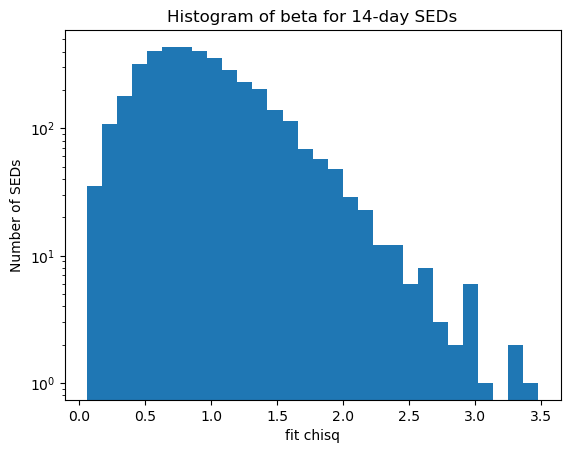

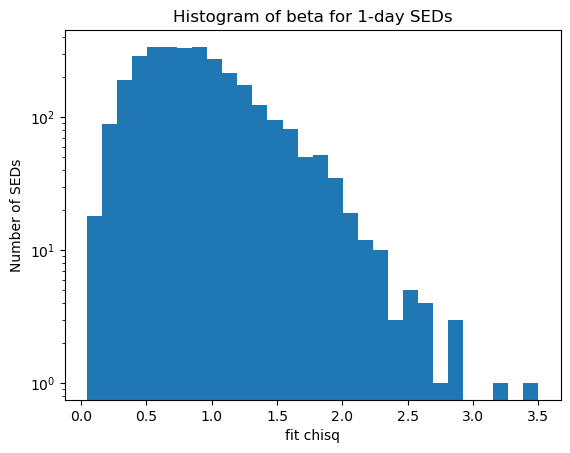

In [109]:
#histogram of chisq
plt.hist(table_14d['fit chisq'],bins=30)
plt.xlabel('fit chisq')
plt.ylabel('Number of SEDs')
plt.title('Histogram of beta for 14-day SEDs')
plt.yscale('log')
plt.show()
plt.hist(table_1d['fit chisq'],bins=30)
plt.xlabel('fit chisq')
plt.ylabel('Number of SEDs')
plt.title('Histogram of beta for 1-day SEDs')
plt.yscale('log')



## Beta分布

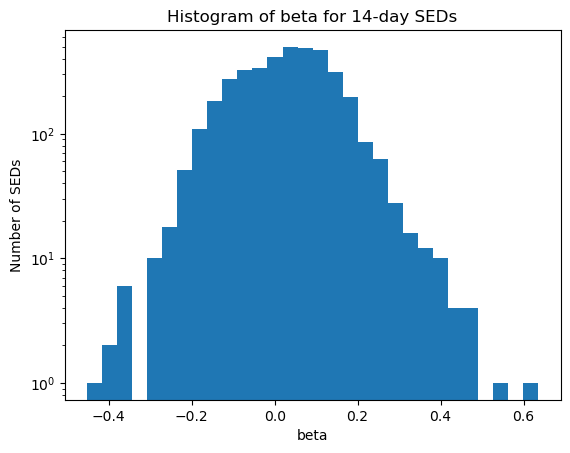

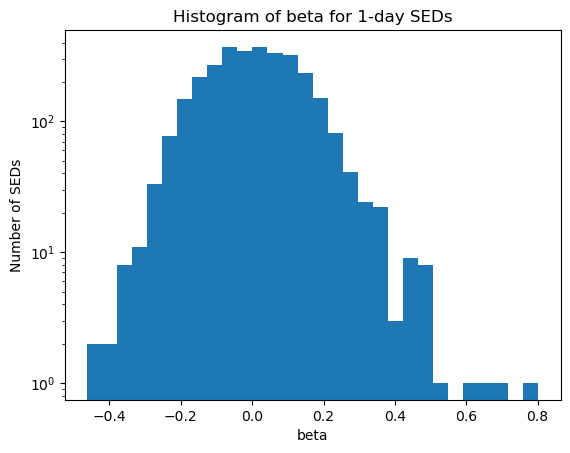

In [110]:
#histogram of beta
import matplotlib.pyplot as plt
plt.hist(table_14d['beta'],bins=30)
plt.xlabel('beta')
plt.ylabel('Number of SEDs')
plt.title('Histogram of beta for 14-day SEDs')
plt.yscale('log')
plt.show()
plt.hist(table_1d['beta'],bins=30)
plt.xlabel('beta')
plt.ylabel('Number of SEDs')
plt.title('Histogram of beta for 1-day SEDs')
plt.yscale('log')

Text(0, 0.5, 'beta_err')

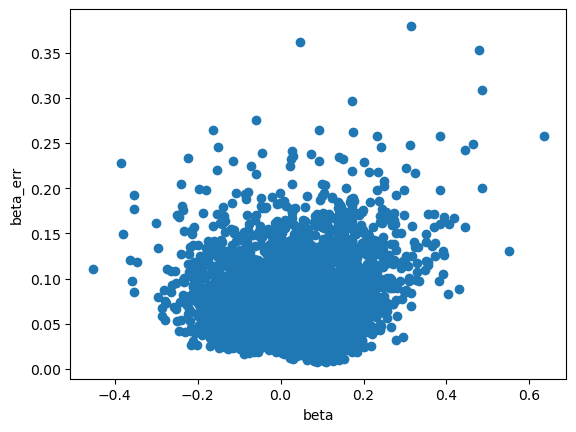

In [111]:
plt.plot(table_14d['beta'], table_14d['beta_err'], 'o')
plt.xlabel('beta')
plt.ylabel('beta_err')

## 負のBeta

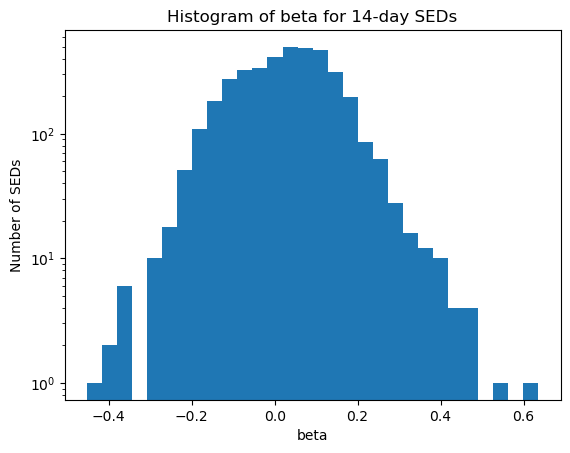

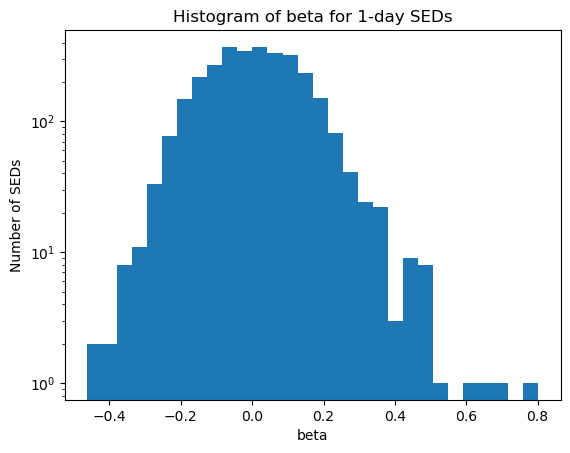

In [116]:
mask_outlayer = (table_14d['beta'] > -1)

import matplotlib.pyplot as plt
plt.hist(table_14d['beta'][mask_outlayer],bins=30)
plt.xlabel('beta')
plt.ylabel('Number of SEDs')
plt.title('Histogram of beta for 14-day SEDs')
plt.yscale('log')
plt.show()
plt.hist(table_1d['beta'],bins=30)
plt.xlabel('beta')
plt.ylabel('Number of SEDs')
plt.title('Histogram of beta for 1-day SEDs')
plt.yscale('log')

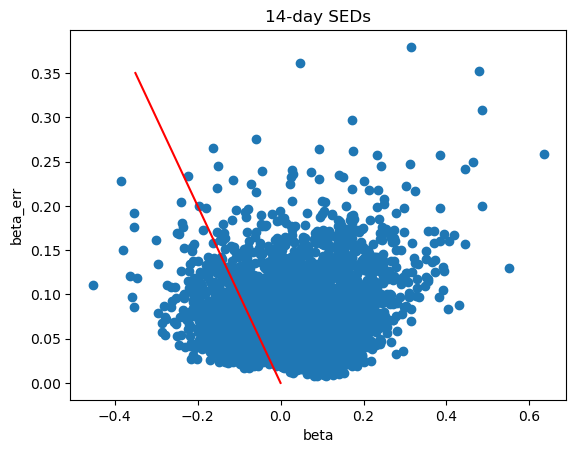

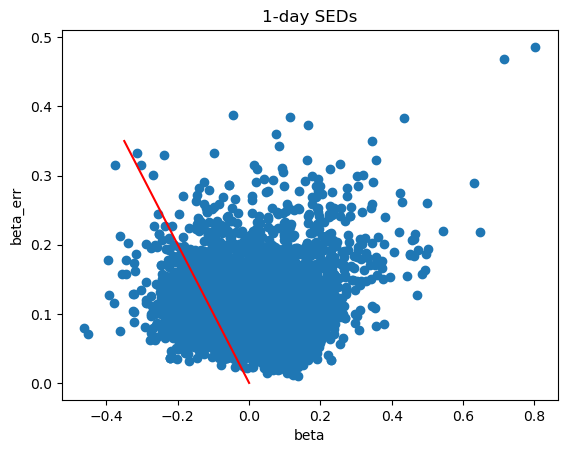

In [117]:
plt.plot(table_14d['beta'][mask_outlayer], table_14d['beta_err'][mask_outlayer], 'o')
# overlay a line, y is bigger than |x|
plt.plot([-0.35,0],[0.35,0],'r-')
plt.xlabel('beta')
plt.ylabel('beta_err')
plt.title('14-day SEDs')
plt.show()


plt.plot(table_1d['beta'], table_1d['beta_err'], 'o')
# overlay a line, y is bigger than |x|
plt.plot([-0.35,0],[0.35,0],'r-')
plt.xlabel('beta')
plt.ylabel('beta_err')
plt.title('1-day SEDs')
plt.show()


### peak有SED
 

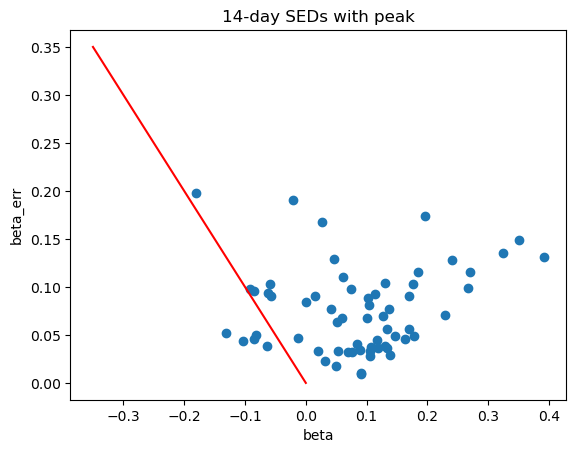

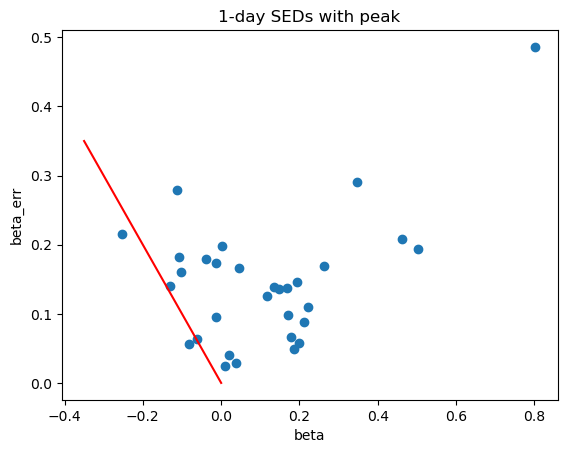

In [124]:
mask_peak_14d = (table_14d['is_peak'] == 1)
mask_peak_1d  = (table_1d['is_peak'] == 1)
plt.plot(table_14d['beta'][mask_peak_14d], table_14d['beta_err'][mask_peak_14d], 'o')
# overlay a line, y is bigger than |x|
plt.plot([-0.35,0],[0.35,0],'r-')
plt.xlabel('beta')
plt.ylabel('beta_err')
plt.title('14-day SEDs with peak')
plt.show()

plt.plot(table_1d['beta'][mask_peak_1d], table_1d['beta_err'][mask_peak_1d], 'o')
# overlay a line, y is bigger than |x|
plt.plot([-0.35,0],[0.35,0],'r-')
plt.xlabel('beta')
plt.ylabel('beta_err')
plt.title('1-day SEDs with peak')
plt.show()

In [125]:
mask = (table_14d['Source Name']=='Mrk421')
table_14d[mask]

fit chisq,alpha,beta,amplitude,x_0,alpha_err,beta_err,amplitude_err,x_0_err,is_peak,nbins,obsdate,Days scale,Index,Source Name,4FGL Name
float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,int16,float32,float64,float64,str11,str12
0.5021336,2.2417357,-0.23954292,0.0035791658,9.535244,1.3563206,0.12679759,0.012610231,0.06815712,0,12,54682.656,14.0,2.0,Mrk421,j1104.4+3812
0.6839688,0.48799357,-0.07541428,5.097439e-05,9.488718,0.3202127,0.03059081,4.0028604e-05,0.0050899624,0,19,54696.656,14.0,2.0,Mrk421,j1104.4+3812
0.52064484,0.670345,-0.08630022,7.8563935e-05,9.490876,0.34303486,0.03334084,6.5966204e-05,0.00623841,0,15,54710.656,14.0,2.0,Mrk421,j1104.4+3812
0.43040165,1.1422708,-0.13450825,0.00018174664,9.500861,0.2574142,0.023892848,0.00011647787,0.007288675,0,18,54724.656,14.0,2.0,Mrk421,j1104.4+3812
0.7939351,0.37937608,-0.03917627,5.169205e-05,9.4843855,0.90959984,0.11089725,9.221917e-05,0.0075143995,0,9,54738.656,14.0,2.0,Mrk421,j1104.4+3812
0.28132963,0.5180877,-0.08238196,3.358631e-05,9.489888,0.48413578,0.04062724,4.6537636e-05,0.0084055895,0,12,54752.656,14.0,2.0,Mrk421,j1104.4+3812
0.62270224,0.7558568,-0.10547491,4.9298356e-05,9.49446,0.3896194,0.033681244,5.258606e-05,0.008656642,0,15,54766.656,14.0,2.0,Mrk421,j1104.4+3812
0.66127425,0.42765433,-0.055306107,3.6479672e-05,9.4880295,0.7748231,0.08961783,5.8743004e-05,0.009032951,0,13,54780.656,14.0,2.0,Mrk421,j1104.4+3812
0.95922136,1.1642624,-0.1420663,0.00021114924,9.499614,0.4795513,0.051253587,0.00022141427,0.014343343,0,17,54794.656,14.0,2.0,Mrk421,j1104.4+3812
